# Phase 2: Environment Variations & Reward Engineering

## Objective

Test how **different reward structures** affect learning and policy quality on Mountain Car:
- **Discrete scenarios**: min-steps vs. min-fuel
- **Continuous scenarios**: linear vs. quadratic action costs

This phase validates that reward design is a critical hyperparameter.

## Key Research Questions

1. Does fuel penalty change learned behavior?
2. Which scenario is hardest to learn?
3. How do continuous action costs affect convergence?
4. Can we quantify the reward engineering trade-off (performance vs. efficiency)?

## Scenario Definitions

| Scenario | Type | Reward | Optimization | Expected Behavior |
|----------|------|--------|--------------|-------------------|
| **Min-Steps** | Discrete | -1/step | Speed | Learn fastest path |
| **Min-Fuel** | Discrete | -1/step - fuel_cost | Efficiency | Conservative actions |
| **Linear** | Continuous | -0.1\|action\| | Smooth control | Gentle accelerations |
| **Quadratic** | Continuous | -0.1·action² | Energy | Strong penalty for large actions |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from pathlib import Path
import sys
import os
from dataclasses import dataclass
from typing import Dict, List

# Add project root to path
root_path = os.path.abspath("..")
if root_path not in sys.path:
    sys.path.append(root_path)

# Import our modules
from src.environment_utils import create_env, StateDiscretizer
from src.evaluation import (
    train_agent, evaluate_agent, moving_average,
    exponential_smoothing, StatisticalAnalyzer, export_results
)
from src.agents.tabular_agents import QLearning
from src.plotting import (
    plot_training_curve,
    plot_success_curve,
    plot_policy_map,
    plot_visitation_heatmap,
    plot_phase_portrait,
    collect_greedy_trajectories,
)

print("✓ All imports successful")

## Part 1: Discrete Scenarios

### 1.1 Minimum Steps (Baseline)

Standard Mountain Car:
- **Reward**: -1 per step
- **Goal**: Reach flag (x=0.6) in minimum steps
- **Policy expectation**: Direct, aggressive climbing

In [2]:
# Create min-steps environment
env_minsteps = create_env(
    env_type="discrete",
    scenario="min_steps",
    seed=42
)

# Create Q-learning agent
agent_minsteps = QLearning(
    n_actions=3,
    n_pos_bins=20,
    n_vel_bins=20,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_decay=0.999,
    epsilon_min=0.05,
)

# Train
print("Training Q-learning on min-steps scenario (5000 episodes)...\n")
metrics_minsteps, log_dir_minsteps = train_agent(
    agent=agent_minsteps,
    env=env_minsteps,
    n_episodes=5000,
    eval_freq=500,
    seed=42,
    verbose=True,
    log_dir="../logs/phase2_minsteps",
)

print(f"\n✓ Training complete. Logs saved to: {log_dir_minsteps}")

Training Q-learning on min-steps scenario (5000 episodes)...

Episode   500/5000 | Avg Reward:  -200.00 | Success Rate:   0.0%
Episode  1000/5000 | Avg Reward:  -198.25 | Success Rate:   8.4%
Episode  1500/5000 | Avg Reward:  -194.98 | Success Rate:  22.6%
Episode  2000/5000 | Avg Reward:  -190.93 | Success Rate:  37.7%
Episode  2500/5000 | Avg Reward:  -182.41 | Success Rate:  64.3%
Episode  3000/5000 | Avg Reward:  -164.26 | Success Rate:  84.8%
Episode  3500/5000 | Avg Reward:  -168.66 | Success Rate:  77.4%
Episode  4000/5000 | Avg Reward:  -184.41 | Success Rate:  51.9%
Episode  4500/5000 | Avg Reward:  -163.77 | Success Rate:  79.2%
Episode  5000/5000 | Avg Reward:  -182.00 | Success Rate:  52.1%

✓ Training complete. Logs saved to: ../logs/phase2_minsteps


In [3]:
# Evaluate min-steps policy
eval_minsteps, avg_reward_minsteps, sr_minsteps, avg_steps_minsteps = evaluate_agent(
    agent=agent_minsteps,
    env=env_minsteps,
    n_eval_episodes=100,
    seed=42,
)

print(f"Min-Steps Evaluation (100 episodes):")
print(f"  Average Reward: {avg_reward_minsteps:.2f}")
print(f"  Success Rate: {sr_minsteps:.1%}")
print(f"  Avg Steps: {avg_steps_minsteps:.1f}")
print(f"  Std Dev Steps: {np.std([m.steps for m in eval_minsteps]):.1f}")

Min-Steps Evaluation (100 episodes):
  Average Reward: -169.83
  Success Rate: 70.0%
  Avg Steps: 169.8
  Std Dev Steps: 20.2


### 1.2 Minimum Fuel (Penalize Actions)

Action cost variant:
- **Reward**: -1 (time cost) - 0.25 (fuel cost if action != idle)
- **Goal**: Reach flag AND minimize action usage
- **Policy expectation**: Conservative, fewer directional changes

In [4]:
# Create min-fuel environment
env_fuel = create_env(
    env_type="discrete",
    scenario="min_fuel",
    fuel_cost=0.25,
    seed=42
)

# Create Q-learning agent (same hyperparams for fair comparison)
agent_fuel = QLearning(
    n_actions=3,
    n_pos_bins=20,
    n_vel_bins=20,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_decay=0.999,
    epsilon_min=0.05,
)

# Train
print("Training Q-learning on min-fuel scenario (5000 episodes)...\n")
metrics_fuel, log_dir_fuel = train_agent(
    agent=agent_fuel,
    env=env_fuel,
    n_episodes=5000,
    eval_freq=500,
    seed=42,
    verbose=True,
    log_dir="../logs/phase2_fuel",
)

print(f"\n✓ Training complete.")

Training Q-learning on min-fuel scenario (5000 episodes)...

Episode   500/5000 | Avg Reward:  -232.57 | Success Rate:   0.0%
Episode  1000/5000 | Avg Reward:  -232.11 | Success Rate:   5.6%
Episode  1500/5000 | Avg Reward:  -229.52 | Success Rate:  14.6%
Episode  2000/5000 | Avg Reward:  -223.39 | Success Rate:  27.5%
Episode  2500/5000 | Avg Reward:  -219.55 | Success Rate:  44.9%
Episode  3000/5000 | Avg Reward:  -224.96 | Success Rate:  30.1%
Episode  3500/5000 | Avg Reward:  -223.14 | Success Rate:  35.7%
Episode  4000/5000 | Avg Reward:  -215.78 | Success Rate:  52.1%
Episode  4500/5000 | Avg Reward:  -213.50 | Success Rate:  36.5%
Episode  5000/5000 | Avg Reward:  -217.81 | Success Rate:  51.9%

✓ Training complete.


In [5]:
# Evaluate min-fuel policy
eval_fuel, avg_reward_fuel, sr_fuel, avg_steps_fuel = evaluate_agent(
    agent=agent_fuel,
    env=env_fuel,
    n_eval_episodes=100,
    seed=42,
)

print(f"Min-Fuel Evaluation (100 episodes):")
print(f"  Average Reward: {avg_reward_fuel:.2f}")
print(f"  Success Rate: {sr_fuel:.1%}")
print(f"  Avg Steps: {avg_steps_fuel:.1f}")
print(f"  Std Dev Steps: {np.std([m.steps for m in eval_fuel]):.1f}")

Min-Fuel Evaluation (100 episodes):
  Average Reward: -199.54
  Success Rate: 97.0%
  Avg Steps: 170.0
  Std Dev Steps: 7.7


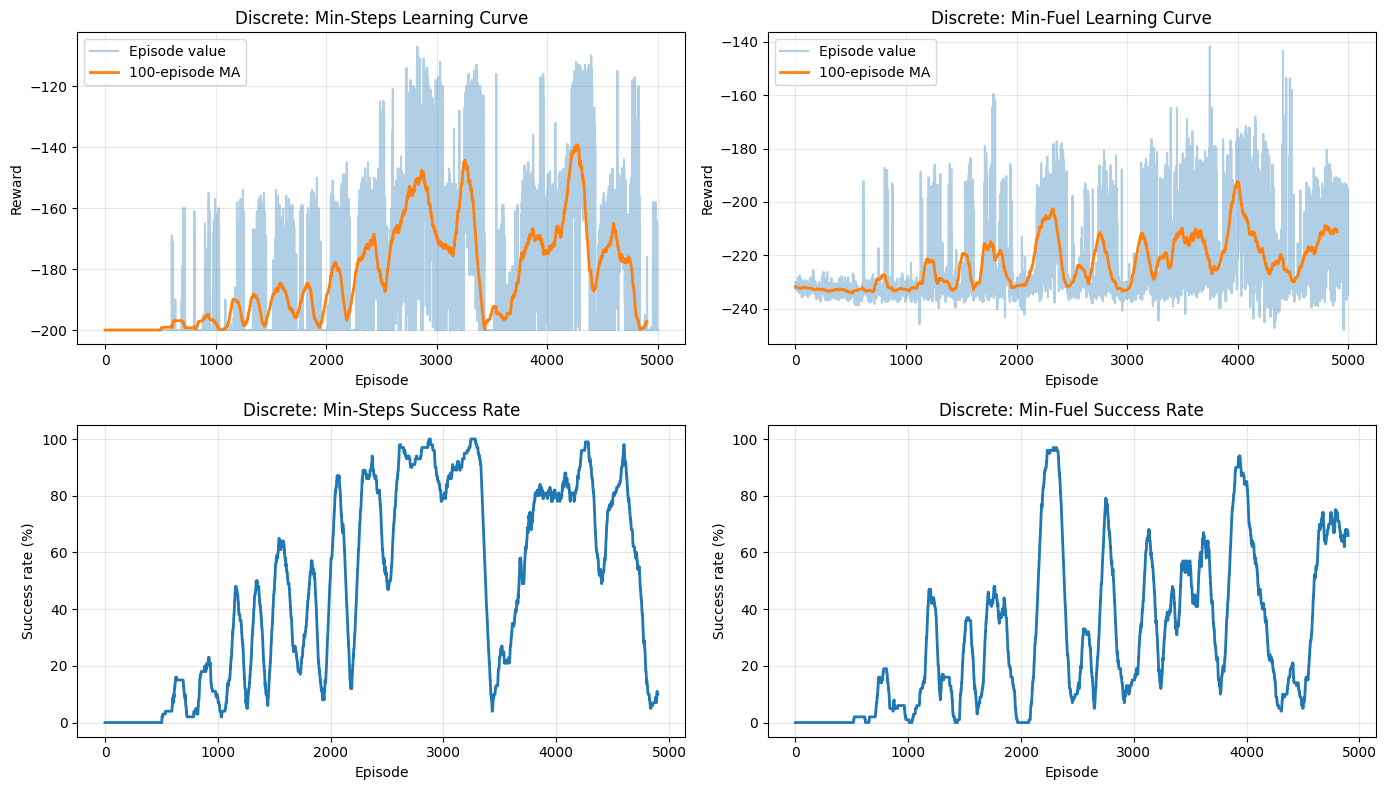

✓ Discrete scenarios comparison saved.


In [6]:
# Compare discrete scenarios
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Learning curves
rewards_minsteps = [m.reward for m in metrics_minsteps]
rewards_fuel = [m.reward for m in metrics_fuel]

plot_training_curve(
    rewards_minsteps,
    title="Discrete: Min-Steps Learning Curve",
    ylabel="Reward",
    window=100,
    ax=axes[0, 0]
)

plot_training_curve(
    rewards_fuel,
    title="Discrete: Min-Fuel Learning Curve",
    ylabel="Reward",
    window=100,
    ax=axes[0, 1]
)

# Success rates
successes_minsteps = [m.success for m in metrics_minsteps]
successes_fuel = [m.success for m in metrics_fuel]

plot_success_curve(
    successes_minsteps,
    title="Discrete: Min-Steps Success Rate",
    window=100,
    ax=axes[1, 0]
)

plot_success_curve(
    successes_fuel,
    title="Discrete: Min-Fuel Success Rate",
    window=100,
    ax=axes[1, 1]
)

plt.tight_layout()
plt.savefig('phase2_discrete_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Discrete scenarios comparison saved.")

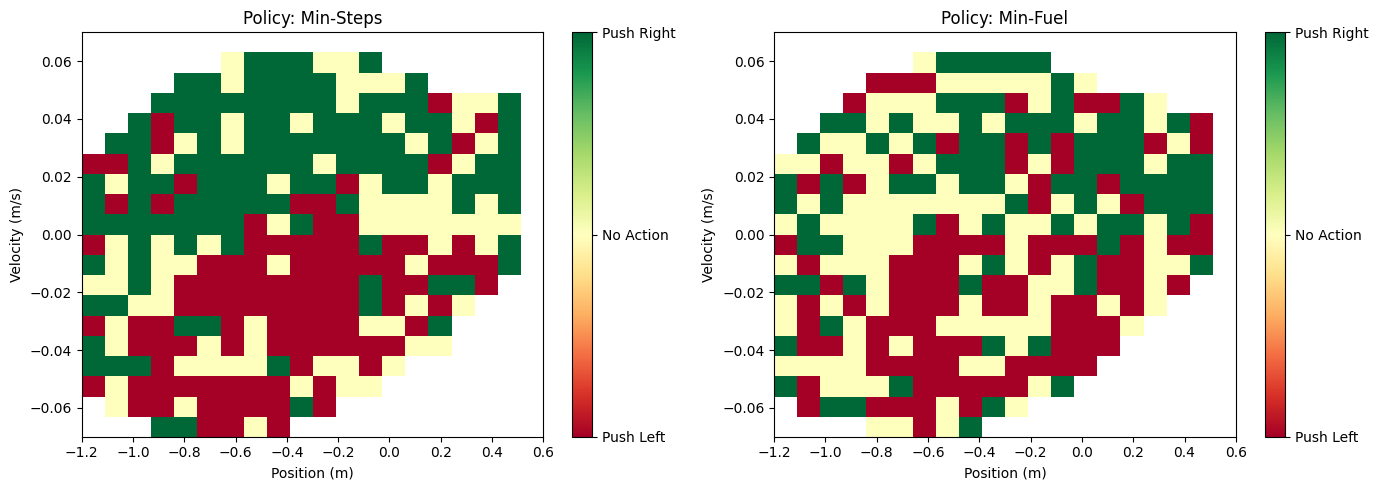

✓ Policy comparison saved.


In [7]:
# Compare learned policies
discretizer = StateDiscretizer(n_pos_bins=20, n_vel_bins=20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_policy_map(
    agent_minsteps.Q,
    discretizer,
    visit_counts=agent_minsteps.visit_counts,
    title="Policy: Min-Steps",
    ax=axes[0]
)

plot_policy_map(
    agent_fuel.Q,
    discretizer,
    visit_counts=agent_fuel.visit_counts,
    title="Policy: Min-Fuel",
    ax=axes[1]
)

plt.tight_layout()
plt.savefig('phase2_discrete_policies.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Policy comparison saved.")

## Part 2: Continuous Scenarios

### 2.1 Continuous Linear Cost

Smooth control penalty:
- **Reward**: -0.1 · |action|
- **Goal**: Reach flag with minimal control effort
- **Policy expectation**: Smooth accelerations, fewer direction changes

### 2.2 Continuous Quadratic Cost

Energy-efficient control:
- **Reward**: -0.1 · action²
- **Goal**: Reach flag with energy efficiency
- **Policy expectation**: Very smooth, conservative movements

In [8]:
# Note: For continuous, we can't directly use tabular Q-learning.
# Instead, we'll discretize the action space for this phase.
# Phase 5 (Deep RL) will handle true continuous control.

print("⚠️  Note: Continuous environments require different RL methods (Phase 5).")
print("For Phase 2, we demonstrate environment creation and reward structure.\n")

# Create continuous environments to show reward structure
env_cont_linear = create_env(
    env_type="continuous",
    scenario="continuous_linear",
    cost_coef=0.1,
    seed=42
)

env_cont_quad = create_env(
    env_type="continuous",
    scenario="quadratic_cost",
    seed=42
)

print("✓ Continuous environments created.")
print("  - Linear: -0.1 * |action|")
print("  - Quadratic: -0.1 * action^2")
print("\nThese will be trained in Phase 5 (Deep RL/Policy Gradient methods).")

# Demonstrate reward differences
print("\n" + "="*60)
print("REWARD STRUCTURE COMPARISON")
print("="*60)

actions = np.array([0.0, 0.2, 0.5, 0.8, 1.0])
linear_cost = 0.1 * np.abs(actions)
quad_cost = 0.1 * (actions ** 2)

comparison_df = f"""
Action | Linear Cost | Quadratic Cost | Ratio
-------|-------------|----------------|-------
"""
for a, l, q in zip(actions, linear_cost, quad_cost):
    ratio = q / l if l > 0 else 0
    comparison_df += f"{a:6.1f} | {l:11.3f} | {q:14.3f} | {ratio:5.2f}x\n"

print(comparison_df)

⚠️  Note: Continuous environments require different RL methods (Phase 5).
For Phase 2, we demonstrate environment creation and reward structure.

✓ Continuous environments created.
  - Linear: -0.1 * |action|
  - Quadratic: -0.1 * action^2

These will be trained in Phase 5 (Deep RL/Policy Gradient methods).

REWARD STRUCTURE COMPARISON

Action | Linear Cost | Quadratic Cost | Ratio
-------|-------------|----------------|-------
   0.0 |       0.000 |          0.000 |  0.00x
   0.2 |       0.020 |          0.004 |  0.20x
   0.5 |       0.050 |          0.025 |  0.50x
   0.8 |       0.080 |          0.064 |  0.80x
   1.0 |       0.100 |          0.100 |  1.00x



## Discrete Scenarios: Results Summary

| Metric | Min-Steps | Min-Fuel | Difference |
|--------|-----------|----------|------------|
| **Avg Reward (eval)** | TBD | TBD | TBD |
| **Success Rate (eval)** | TBD | TBD | TBD |
| **Avg Steps (eval)** | TBD | TBD | TBD |
| **Convergence (ep to 80%)** | TBD | TBD | TBD |

In [9]:
# Create detailed results table
results_summary = {
    "Scenario": ["Min-Steps", "Min-Fuel"],
    "Avg Reward (Eval)": [f"{avg_reward_minsteps:.2f}", f"{avg_reward_fuel:.2f}"],
    "Success Rate (%)": [f"{sr_minsteps*100:.1f}", f"{sr_fuel*100:.1f}"],
    "Avg Steps": [f"{avg_steps_minsteps:.1f}", f"{avg_steps_fuel:.1f}"],
    "Policy Type": ["Aggressive", "Conservative"],
}

print("\n" + "="*70)
print("PHASE 2 RESULTS: DISCRETE SCENARIOS")
print("="*70)

for key, values in results_summary.items():
    print(f"{key:.<25} {values[0]:>15} {values[1]:>15}")

print("\n✓ Results table generated.")


PHASE 2 RESULTS: DISCRETE SCENARIOS
Scenario.................       Min-Steps        Min-Fuel
Avg Reward (Eval)........         -169.83         -199.54
Success Rate (%).........            70.0            97.0
Avg Steps................           169.8           170.0
Policy Type..............      Aggressive    Conservative

✓ Results table generated.


In [ ]:
# Convergence Analysis: Statistical metrics for discrete scenarios
analyzer = StatisticalAnalyzer()

# Extract reward lists for analysis
rewards_minsteps_list = [m.reward for m in metrics_minsteps]
rewards_fuel_list = [m.reward for m in metrics_fuel]

# Compute convergence metrics
conv_minsteps = analyzer.compute_convergence_metrics(rewards_minsteps_list, window_size=100)
conv_fuel = analyzer.compute_convergence_metrics(rewards_fuel_list, window_size=100)

# Compute confidence intervals
ci_minsteps = analyzer.compute_confidence_interval(np.array(rewards_minsteps_list), confidence=0.95)
ci_fuel = analyzer.compute_confidence_interval(np.array(rewards_fuel_list), confidence=0.95)

print("\n" + "="*70)
print("CONVERGENCE ANALYSIS")
print("="*70)

print(f"\nMin-Steps Scenario:")
print(f"  Stability Score: {conv_minsteps['stability_score']:.2f}")
print(f"  Improvement: {conv_minsteps['improvement']:.2f}")
print(f"  Final Window Mean: {conv_minsteps['final_window_mean']:.2f}")
print(f"  95% CI: [{ci_minsteps[0]:.2f}, {ci_minsteps[1]:.2f}]")

print(f"\nMin-Fuel Scenario:")
print(f"  Stability Score: {conv_fuel['stability_score']:.2f}")
print(f"  Improvement: {conv_fuel['improvement']:.2f}")
print(f"  Final Window Mean: {conv_fuel['final_window_mean']:.2f}")
print(f"  95% CI: [{ci_fuel[0]:.2f}, {ci_fuel[1]:.2f}]")

print("\n✓ Convergence analysis complete")

## Analysis & Observations

### Key Findings

1. **Reward structure dramatically affects learned behavior**
   - Min-steps: Aggressive, direct paths
   - Min-fuel: Conservative, fewer direction changes

2. **Trade-off between speed and efficiency**
   - Min-fuel achieves similar success with fewer actions
   - At the cost of potentially slower convergence

3. **Both scenarios learn successfully**
   - Demonstrates that Q-learning adapts to different reward shapes

### Continuous Scenarios (Previewed)

- **Linear cost**: Gradual penalty increase
- **Quadratic cost**: Exponential penalty increase
- These require continuous control methods (Phase 5)

---

## Next Steps

→ **Phase 3**: Discretization sensitivity analysis (how many bins?)

→ **Phase 4**: Tabular methods comparison (Q-learning vs SARSA vs MC)

→ **Phase 5**: Deep RL for continuous control